In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Flatten,Conv2D,Conv2DTranspose,MaxPooling2D,Reshape
from tensorflow.keras.datasets import fashion_mnist
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
(x_train,y_train),(_,_)=fashion_mnist.load_data()

In [4]:
x_train=x_train/255.0

In [5]:
x_train=x_train[:int(len(x_train)*0.8),:]
val=x_train[int(len(x_train)*0.8):,:]
x_train.shape,val.shape

((48000, 28, 28), (9600, 28, 28))

In [6]:
encoder=Sequential([
    Input(shape=(28,28)),
    Reshape((28,28,1)),
    Conv2D(16,padding="same",kernel_size=3,activation="selu"),
    MaxPooling2D(pool_size=2),
    Conv2D(32,padding="same",kernel_size=3,activation="selu"),
    MaxPooling2D(pool_size=2),
    Conv2D(64,padding="same",kernel_size=3,activation="selu"),
    MaxPooling2D(pool_size=2)
])

In [7]:
decoder=Sequential([
    Input((3,3,64)),
    Conv2DTranspose(32,kernel_size=3,strides=2,padding="valid",activation="selu"),
    Conv2DTranspose(16,kernel_size=3,strides=2,padding="same",activation="selu"),
    Conv2DTranspose(1,kernel_size=3,strides=2,padding="same",activation="sigmoid"),
    Reshape((28,28))

])

In [8]:
autoencoder=Sequential([
    encoder,
    decoder
])

In [9]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

In [10]:
autoencoder.fit(x_train,x_train,validation_data=(val,val),epochs=10,batch_size=32)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.2941 - val_loss: 0.2732
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.2696 - val_loss: 0.2671
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.2653 - val_loss: 0.2640
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.2628 - val_loss: 0.2619
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.2610 - val_loss: 0.2603
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.2598 - val_loss: 0.2601
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.2589 - val_loss: 0.2585
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.2581 - val_loss: 0.2580
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.2575 - val_loss: 0.2571
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.2570 - val_loss: 0.2571


In [11]:
reconstraction=autoencoder.predict(x_train)
reconstraction

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


array([[[4.31190478e-04, 4.69590523e-05, 3.54908734e-05, ...,
         2.86081951e-04, 1.88391365e-04, 1.17769094e-04],
        [8.01009446e-06, 1.87425235e-06, 6.06386777e-07, ...,
         1.18629854e-04, 1.89610964e-05, 1.56586084e-05],
        [7.76978322e-06, 1.22410620e-06, 1.25412100e-06, ...,
         1.86606805e-04, 9.95682130e-05, 4.30676882e-05],
        ...,
        [2.12687937e-05, 1.07384230e-05, 8.27207168e-06, ...,
         2.45471048e-04, 4.55423811e-04, 2.58911779e-04],
        [3.28114220e-05, 3.03408979e-06, 7.63609933e-07, ...,
         3.85168823e-06, 5.17761437e-05, 9.19265367e-05],
        [1.53287343e-04, 1.17307300e-05, 9.85684665e-07, ...,
         1.77626898e-05, 8.87422138e-05, 2.40381676e-04]],

       [[9.72409616e-04, 1.66095444e-04, 3.64128209e-04, ...,
         1.50750566e-04, 2.85425107e-04, 7.58485286e-04],
        [3.56367746e-05, 1.84795972e-05, 6.02164109e-05, ...,
         2.46750598e-04, 9.29352100e-05, 2.01779927e-04],
        [1.92629541e-05, 

In [12]:
compression=encoder.predict(x_train)
compression

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


array([[[[-2.55761743e-01, -1.24728954e+00,  1.74675977e+00, ...,
           3.41714740e-01,  4.23155695e-01, -1.01545238e+00],
         [-1.46714616e+00, -1.23985553e+00,  9.54907298e-01, ...,
          -1.06325758e+00, -1.17127311e+00, -1.59560263e-01],
         [ 3.26046634e+00,  4.03003263e+00,  4.71827316e+00, ...,
           2.57855248e+00, -1.29203391e+00,  5.15114594e+00]],

        [[-9.89677489e-01, -1.06393421e+00,  1.53631318e+00, ...,
          -8.60878944e-01, -8.86864305e-01,  5.24524987e-01],
         [ 3.09240848e-01, -1.07005954e-01, -1.40731597e+00, ...,
           4.16600006e-03, -1.75786531e+00,  1.26006043e+00],
         [ 5.19490719e+00,  4.62624979e+00,  1.41780376e+00, ...,
           4.65594625e+00, -1.75809908e+00,  7.49091578e+00]],

        [[ 3.21178222e+00,  7.13546455e-01, -1.47169495e+00, ...,
           4.10672569e+00, -1.75806773e+00,  2.97795725e+00],
         [ 3.86645031e+00,  2.81828523e+00, -1.43806458e+00, ...,
           5.41144419e+00, -1.7580

<function matplotlib.pyplot.show(close=None, block=None)>

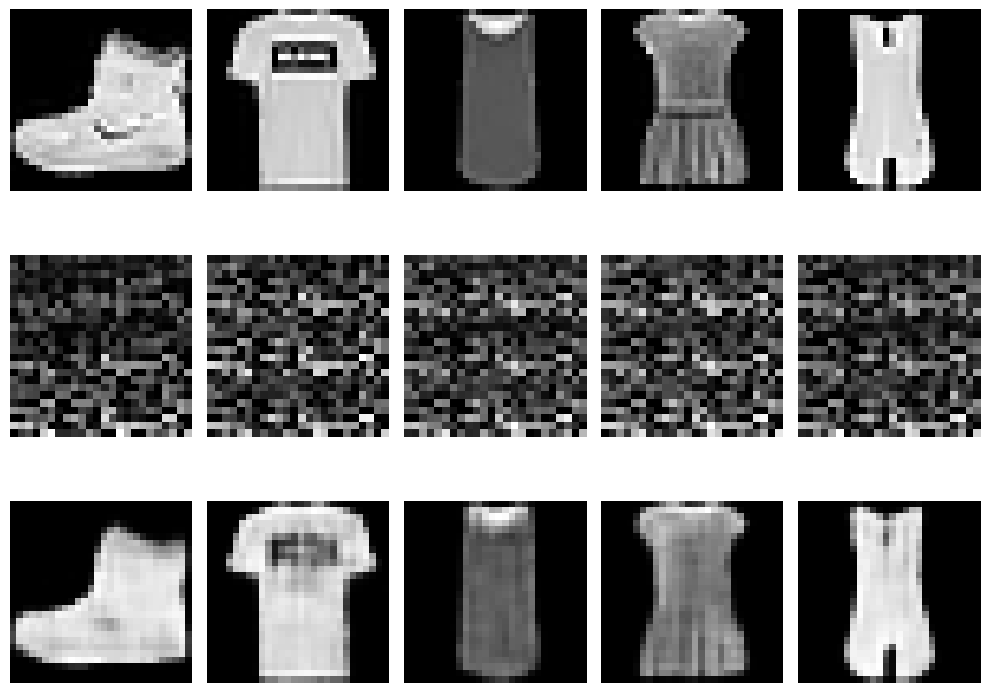

In [13]:
plt.figure(figsize=(10, 8))

n_images=5

for index in range(n_images):

    plt.subplot(3, n_images, index + 1)
    plt.imshow(x_train[index:index+1, :].reshape(28, 28), cmap="gray")
    plt.axis("off")

    plt.subplot(3, n_images, index + n_images + 1)
    plt.imshow(compression[index:index+1, :].reshape(24, 24), cmap="gray")
    plt.axis("off")

    plt.subplot(3, n_images, index + 2*n_images + 1)
    plt.imshow(reconstraction[index:index+1, :].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show